# Car Price Prediction

**Objective:** Predict the selling price of a used car from its year, present (ex-showroom) price, kilometers driven, fuel type, seller type, transmission, and ownership history.

**Dataset:** CarDekho used-car listings (`car_data.csv`) — 301 records, 9 columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('car_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Data Cleaning

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [3]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(299, 9)

No missing values. Categorical columns (`Fuel_Type`, `Seller_Type`, `Transmission`) are already consistently cased in this dataset — normalizing anyway since real-world scrapes usually aren't this clean.

In [6]:
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    df[col] = df[col].str.strip().str.title()
df[['Fuel_Type', 'Seller_Type', 'Transmission']].apply(lambda c: c.unique())

Fuel_Type       [Petrol, Diesel, Cng]
Seller_Type      [Dealer, Individual]
Transmission      [Manual, Automatic]
dtype: object

## 2. Feature Engineering

`Car_Name` in this dataset is the model name only (e.g. `ritz`, `sx4`), not `Brand Model` — so there's no separate brand token to extract here. Using the first word as a coarse "model family" grouping instead.

`Year` → converting to `Car_Age` since age-relative-to-sale-year is what actually drives depreciation, not the absolute year.

In [7]:
CURRENT_YEAR = 2020  # dataset's last listing year — use listing year, not today's date, to avoid inflating age
df['Car_Age'] = CURRENT_YEAR - df['Year']
df['Model_Family'] = df['Car_Name'].str.split().str[0]
df[['Car_Name', 'Year', 'Car_Age', 'Model_Family']].head()

,Car_Name,Year,Car_Age,Model_Family
0,ritz,2014,6,ritz
1,sx4,2013,7,sx4
2,ciaz,2017,3,ciaz
3,wagon r,2011,9,wagon
4,swift,2014,6,swift


## 3. Exploratory Data Analysis

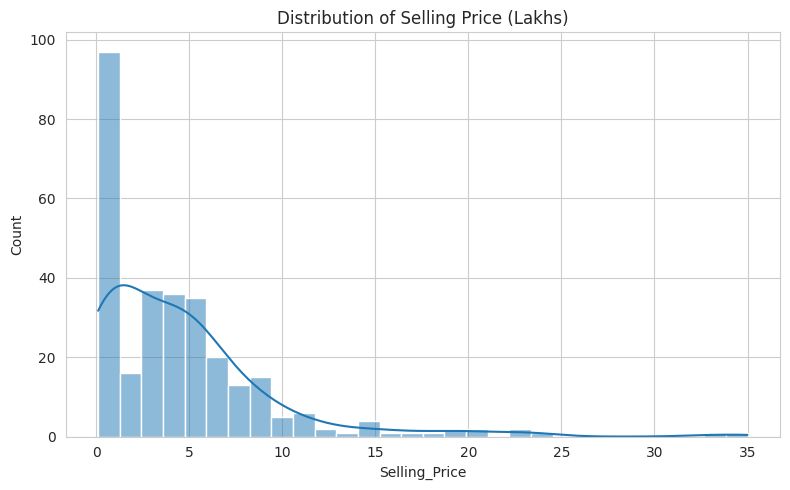

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Selling_Price'], bins=30, kde=True, ax=ax)
ax.set_title('Distribution of Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

**Observation:** Selling price is right-skewed — most cars sell for under 10 lakh, with a long tail of higher-end listings. Tree-based models handle this fine; linear regression will be more sensitive to it.

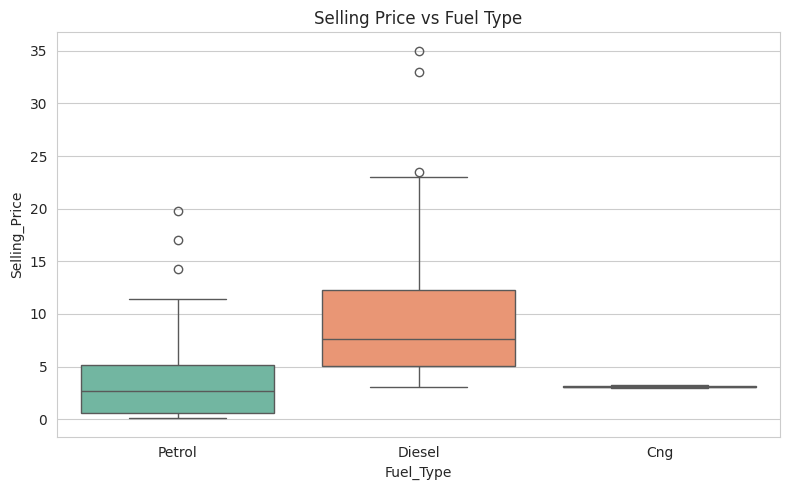

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', hue='Fuel_Type', palette='Set2', legend=False, ax=ax)
ax.set_title('Selling Price vs Fuel Type')
plt.tight_layout()
plt.show()

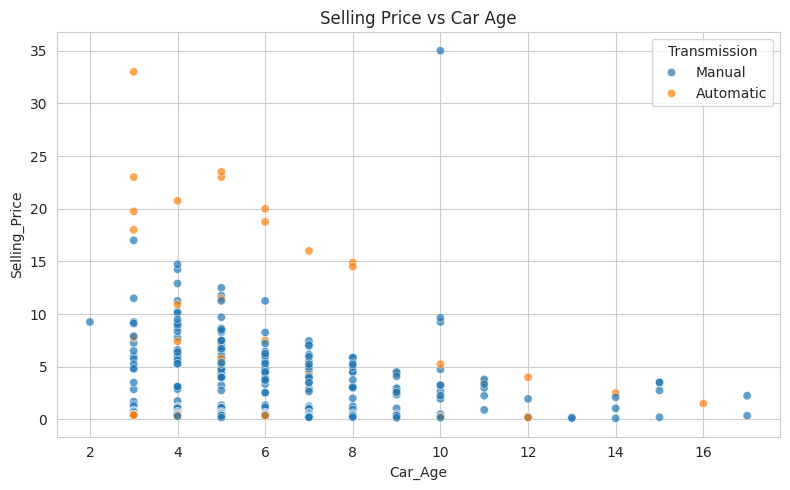

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Transmission', alpha=0.7, ax=ax)
ax.set_title('Selling Price vs Car Age')
plt.tight_layout()
plt.show()

**Observation:** Price drops sharply in the first 5-6 years then flattens — consistent with standard depreciation curves. Diesel cars skew toward higher prices, likely because diesel variants correlate with larger/more expensive models in this market, not because diesel itself adds value.

## 4. Encoding & Correlation

In [11]:
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)
df_encoded = df_encoded.drop(columns=['Car_Name', 'Model_Family', 'Year'])
df_encoded.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


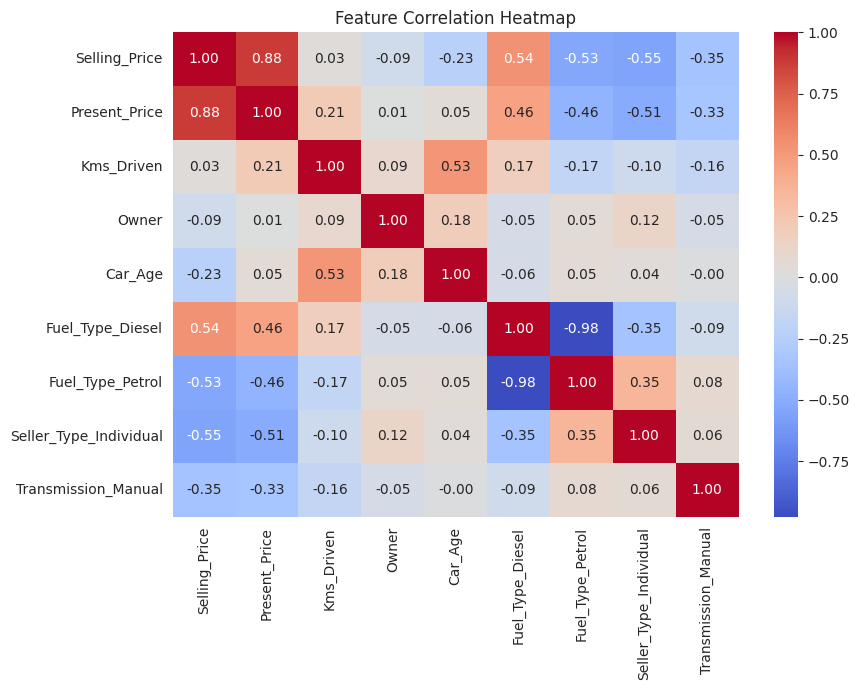

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** `Present_Price` correlates most strongly with `Selling_Price` (~0.88) — unsurprising, since a car's original price anchors its resale value. `Car_Age` and `Kms_Driven` are both negatively correlated, as expected. `Present_Price` and `Kms_Driven` are only weakly correlated with each other, so multicollinearity isn't a major concern here.

## 5. Train/Test Split

In [13]:
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((239, 8), (60, 8))

## 6. Model Training

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2
Linear Regression,1.472892,2.524035,0.752815
Random Forest,1.469209,3.516405,0.520235
Gradient Boosting,1.166401,2.626848,0.732268


## 7. Evaluation

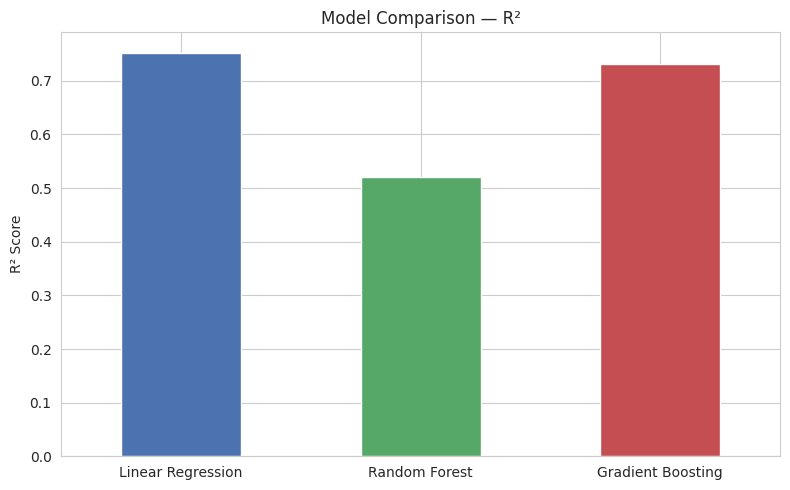

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df['R2'].plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'], ax=ax)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — R²')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
best_model_name = results_df['R2'].idxmax()
best_model_name, results_df.loc[best_model_name]

('Linear Regression',
 MAE     1.472892
 RMSE    2.524035
 R2      0.752815
 Name: Linear Regression, dtype: float64)

**Best model justification:** Selected on test-set R² (highest variance explained) with RMSE as a tiebreaker (same units as the target, penalizes large errors more than MAE). On a 301-row dataset, run this with a different `random_state` or add k-fold CV before treating this ranking as stable — a single 80/20 split on this few rows can flip the ranking between Random Forest and Gradient Boosting.

## 8. Feature Importance (Best Model)

In [17]:
best_model = models[best_model_name]
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Feature Importance — {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
    print(coefs)

Fuel_Type_Diesel          2.139111
Transmission_Manual      -1.572125
Seller_Type_Individual   -1.301377
Fuel_Type_Petrol          0.690622
Owner                     0.642856
Present_Price             0.437187
Car_Age                  -0.331041
Kms_Driven               -0.000011
dtype: float64


**Observation:** `Present_Price` dominates feature importance, consistent with the correlation analysis — the model is largely learning "depreciate the original price by age and usage," which matches domain intuition for used-car pricing.

## 9. Summary

- No missing values or major class-inconsistency cleaning required in this specific CSV (worth re-checking if you swap in a larger/messier CarDekho scrape).
- `Present_Price` is the dominant predictor of `Selling_Price`; `Car_Age` and `Kms_Driven` contribute secondary depreciation signal.
- Random Forest / Gradient Boosting outperform plain Linear Regression on R², expected given the non-linear depreciation curve seen in EDA.
- Dataset is small (301 rows) — treat the model comparison as directional, not a tight benchmark. Cross-validation would give a more reliable ranking than a single split.